In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [3]:
df.to_csv("titanic.csv", index=False)

print("Saved analytics/titanic.csv")

Saved analytics/titanic.csv


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("\nData types:")
print(df.dtypes)



Data types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [6]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
print("\nMissing percentages:")
missing_percentage = df.isna().mean() * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


Missing percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [8]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing-Value Treatment

Missing values are handled according to the project requirements:

- Columns with less than 5% missing values: affected rows are dropped.
- Columns with 5%–30% missing values: values are imputed.
- Columns with very high missingness: the column is dropped unless a missing category is more appropriate.

The exact missing percentages and the resulting treatment are documented below.

In [9]:
missing_pct = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": missing_pct
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

display(missing_summary)

,missing_count,missing_percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


In [10]:
clean_df = df.copy()

In [11]:
for column in missing_summary.index:
    percentage = missing_pct[column]

    if percentage < 5:
        print(f"{column}: {percentage:.2f}% → drop affected rows")

    elif percentage <= 30:
        print(f"{column}: {percentage:.2f}% → impute")

    else:
        print(f"{column}: {percentage:.2f}% → very high missingness")

deck: 77.22% → very high missingness
age: 19.87% → impute
embarked: 0.22% → drop affected rows
embark_town: 0.22% → drop affected rows


In [23]:
clean_df = clean_df.drop(columns=["deck"], errors="ignore")

clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

clean_df["embarked"] = clean_df["embarked"].fillna(
    clean_df["embarked"].mode()[0]
)
clean_df["embark_town"] = clean_df["embark_town"].fillna(
    clean_df["embark_town"].mode()[0]
)



In [14]:
print("Missing values after cleaning:")
print(clean_df.isna().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


### Cleaning Decisions

- `deck` was dropped because it has very high missingness and is not required for the classification task.
- `age` was median-imputed because its missingness falls within the project's 5%–30% imputation range. Median imputation is less sensitive to extreme values than mean imputation.
- `embarked` was mode-imputed because it is a categorical variable with a relatively small amount of missing data.
- `embark_town` was also mode-imputed for the same reason as 'embarked'
- Columns with missingness below 5% would have had their affected rows removed according to the project rule.

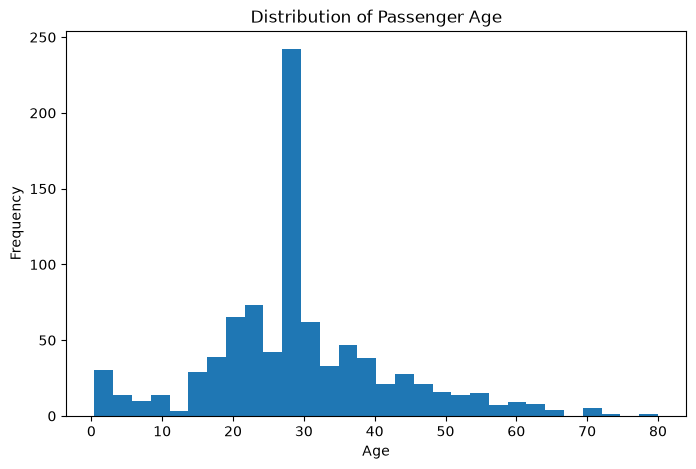

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(clean_df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Age")
plt.show()

C:\Users\karth\AppData\Local\Temp\ipykernel_9264\865615874.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df["age"].dropna(), vert=False)


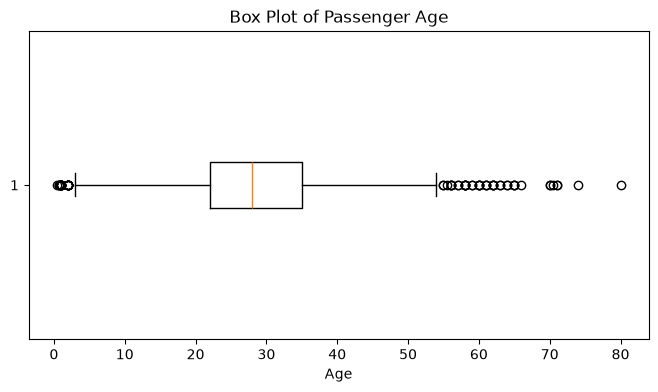

In [16]:
plt.figure(figsize=(8, 4))
plt.boxplot(clean_df["age"].dropna(), vert=False)
plt.xlabel("Age")
plt.title("Box Plot of Passenger Age")
plt.show()

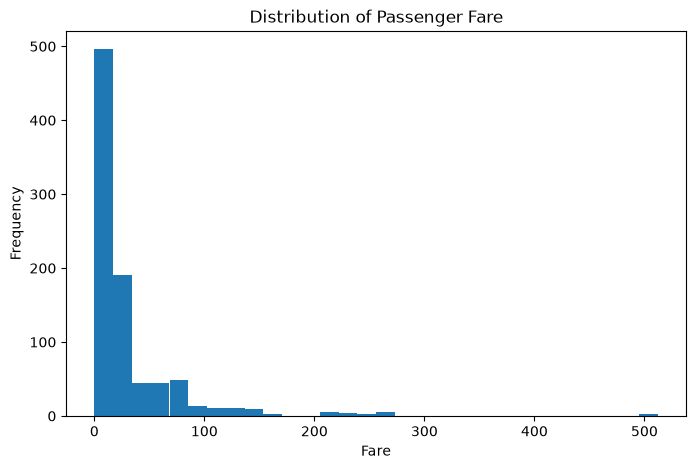

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["fare"], bins=30)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Fare")
plt.show()

C:\Users\karth\AppData\Local\Temp\ipykernel_9264\3125012752.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df["fare"].dropna(), vert=False)


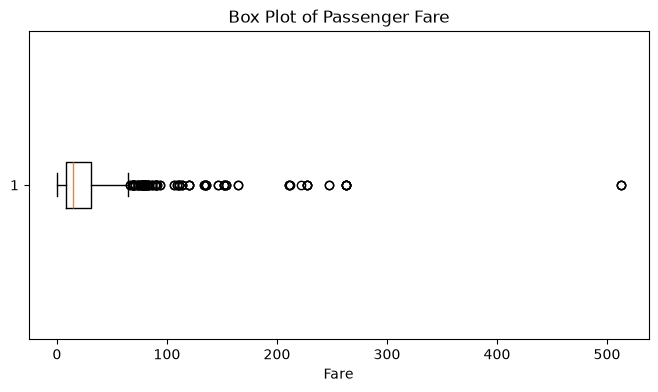

In [18]:
plt.figure(figsize=(8, 4))
plt.boxplot(clean_df["fare"].dropna(), vert=False)
plt.xlabel("Fare")
plt.title("Box Plot of Passenger Fare")
plt.show()

In [19]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound

In [20]:
age_outliers, age_lower, age_upper = iqr_outlier_count(
    clean_df["age"]
)

fare_outliers, fare_lower, fare_upper = iqr_outlier_count(
    clean_df["fare"]
)

print("Age outliers:", age_outliers)
print("Age IQR bounds:", age_lower, "to", age_upper)

print("\nFare outliers:", fare_outliers)
print("Fare IQR bounds:", fare_lower, "to", fare_upper)

Age outliers: 66
Age IQR bounds: 2.5 to 54.5

Fare outliers: 116
Fare IQR bounds: -26.724 to 65.6344


In [21]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print(f"Mean: {fare_mean:.2f}")
print(f"Median: {fare_median:.2f}")
print(f"Mode: {fare_mode:.2f}")

Mean: 32.20
Median: 14.45
Mode: 8.05


In [22]:
if fare_mean > fare_median > fare_mode:
    print("Fare distribution is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("Fare distribution is left-skewed.")
else:
    print("Fare skew direction is not determined by a simple mean-median-mode ordering.")

Fare distribution is right-skewed.


In [24]:
df
clean_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


## Bivariate Analysis

This section examines the relationship between passenger characteristics and survival.

In [25]:
male_mask = clean_df["sex"] == "male"
female_mask = clean_df["sex"] == "female"

male_survival_rate = clean_df.loc[male_mask, "survived"].mean()
female_survival_rate = clean_df.loc[female_mask, "survived"].mean()

print(f"Male survival rate: {male_survival_rate:.2%}")
print(f"Female survival rate: {female_survival_rate:.2%}")

Male survival rate: 18.89%
Female survival rate: 74.20%


In [26]:
survival_by_sex = pd.DataFrame({
    "sex": ["male", "female"],
    "survival_rate": [
        male_survival_rate,
        female_survival_rate
    ]
})

display(survival_by_sex)

,sex,survival_rate
0,male,0.188908
1,female,0.742038


In [27]:
pclass_1_mask = clean_df["pclass"] == 1
pclass_2_mask = clean_df["pclass"] == 2
pclass_3_mask = clean_df["pclass"] == 3

pclass_1_survival = clean_df.loc[
    pclass_1_mask, "survived"
].mean()

pclass_2_survival = clean_df.loc[
    pclass_2_mask, "survived"
].mean()

pclass_3_survival = clean_df.loc[
    pclass_3_mask, "survived"
].mean()

print(f"1st class survival rate: {pclass_1_survival:.2%}")
print(f"2nd class survival rate: {pclass_2_survival:.2%}")
print(f"3rd class survival rate: {pclass_3_survival:.2%}")

1st class survival rate: 62.96%
2nd class survival rate: 47.28%
3rd class survival rate: 24.24%


In [28]:
survival_by_pclass = pd.DataFrame({
    "pclass": [1, 2, 3],
    "survival_rate": [
        pclass_1_survival,
        pclass_2_survival,
        pclass_3_survival
    ]
})

display(survival_by_pclass)

,pclass,survival_rate
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [29]:
female_first_mask = (
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 1)
)

female_second_mask = (
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 2)
)

female_third_mask = (
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 3)
)

male_first_mask = (
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 1)
)

male_second_mask = (
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 2)
)

male_third_mask = (
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 3)
)

In [30]:
sex_pclass_survival = pd.DataFrame({
    "group": [
        "Female, 1st class",
        "Female, 2nd class",
        "Female, 3rd class",
        "Male, 1st class",
        "Male, 2nd class",
        "Male, 3rd class"
    ],
    "survival_rate": [
        clean_df.loc[female_first_mask, "survived"].mean(),
        clean_df.loc[female_second_mask, "survived"].mean(),
        clean_df.loc[female_third_mask, "survived"].mean(),
        clean_df.loc[male_first_mask, "survived"].mean(),
        clean_df.loc[male_second_mask, "survived"].mean(),
        clean_df.loc[male_third_mask, "survived"].mean()
    ]
})

display(sex_pclass_survival)

,group,survival_rate
0,"Female, 1st class",0.968085
1,"Female, 2nd class",0.921053
2,"Female, 3rd class",0.500000
3,"Male, 1st class",0.368852
4,"Male, 2nd class",0.157407
5,"Male, 3rd class",0.135447


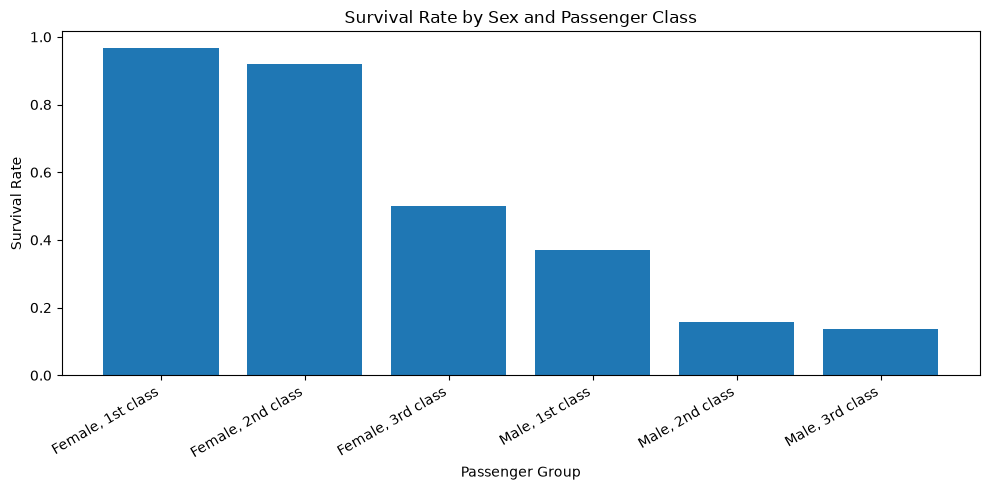

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(
    sex_pclass_survival["group"],
    sex_pclass_survival["survival_rate"]
)

plt.xlabel("Passenger Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Passenger Class")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [32]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[correlation_columns].corr()

display(correlation_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


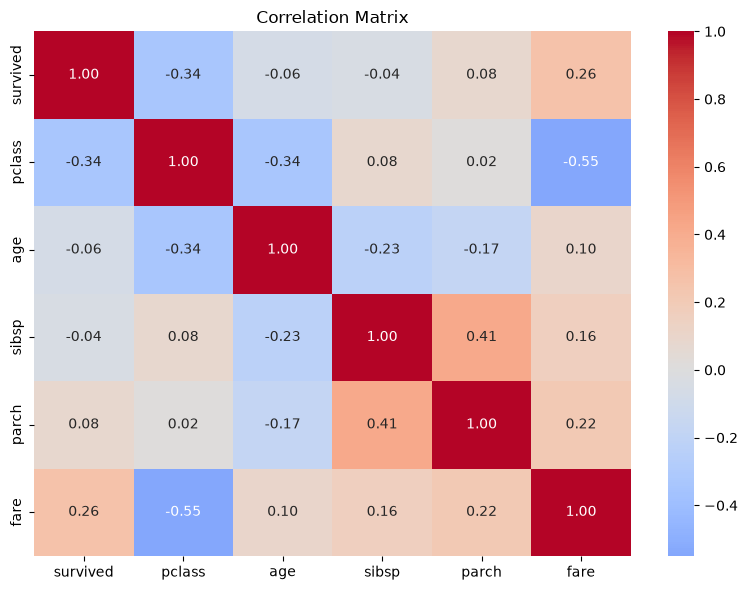

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [34]:
import numpy as np

corr_pairs = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = corr_pairs.stack()

strongest_correlations = (
    corr_pairs.abs()
    .sort_values(ascending=False)
    .head(2)
)

print("Two strongest absolute off-diagonal correlations:")
print(strongest_correlations)

Two strongest absolute off-diagonal correlations:
pclass  fare     0.549500
sibsp   parch    0.414838
dtype: float64


In [35]:
for pair in strongest_correlations.index:
    value = correlation_matrix.loc[pair[0], pair[1]]
    print(f"{pair[0]} vs {pair[1]}: {value:.3f}")

pclass vs fare: -0.549
sibsp vs parch: 0.415


### Multi-variate EDA

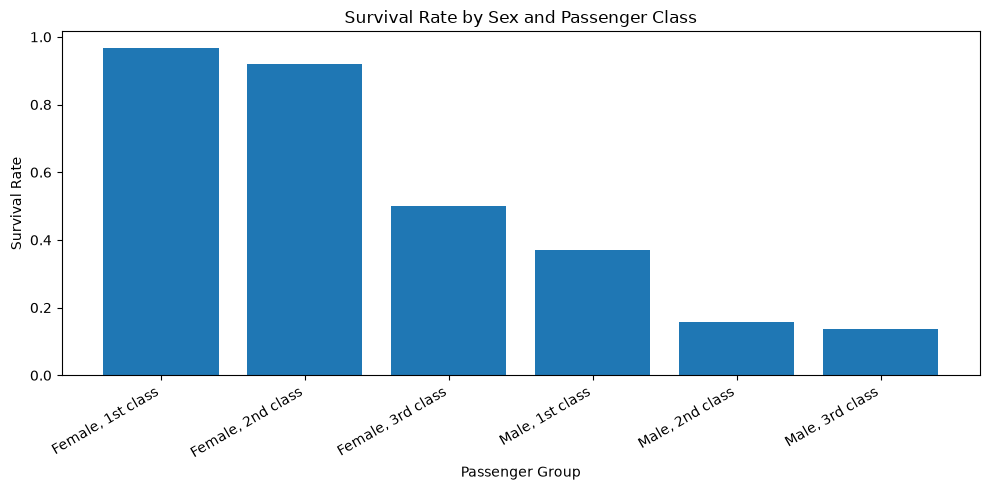

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    sex_pclass_survival["group"],
    sex_pclass_survival["survival_rate"]
)

plt.xlabel("Passenger Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Passenger Class")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Interpretation

Survival rates differ substantially across passenger groups. Female passengers generally had higher survival rates than male passengers within the same passenger class. Passenger class also shows a strong association with survival, with higher-class passengers generally having better survival outcomes.

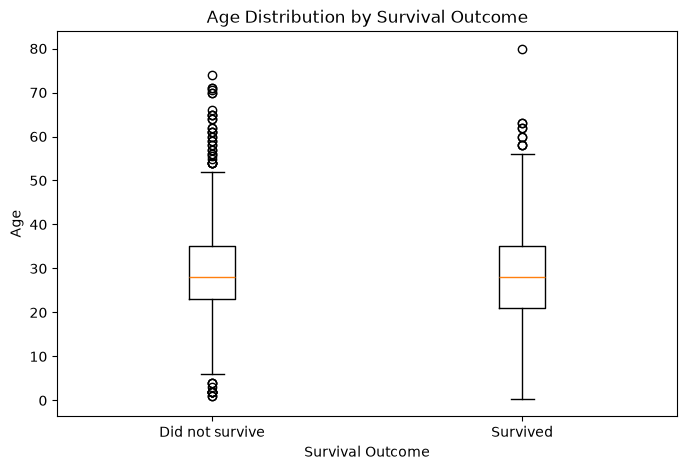

In [38]:
plt.figure(figsize=(8, 5))

survived_ages = clean_df.loc[
    clean_df["survived"] == 1,
    "age"
]

not_survived_ages = clean_df.loc[
    clean_df["survived"] == 0,
    "age"
]

plt.boxplot(
    [not_survived_ages, survived_ages],
    tick_labels=["Did not survive", "Survived"]
)

plt.xlabel("Survival Outcome")
plt.ylabel("Age")
plt.title("Age Distribution by Survival Outcome")

plt.show()

### Interpretation

The age distributions of survivors and non-survivors overlap substantially, indicating that age alone does not completely separate the two groups. The medians and spread can nevertheless reveal whether one survival group tends to contain younger or older passengers. The presence of overlapping distributions suggests that age is more useful when considered together with other passenger characteristics.

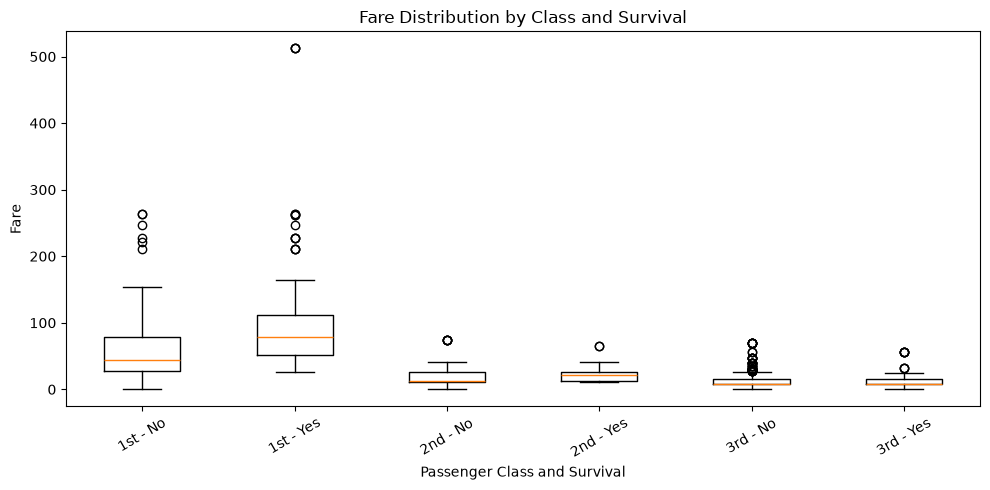

In [39]:
plt.figure(figsize=(10, 5))

groups = [
    clean_df.loc[
        (clean_df["pclass"] == 1) &
        (clean_df["survived"] == 0),
        "fare"
    ],
    clean_df.loc[
        (clean_df["pclass"] == 1) &
        (clean_df["survived"] == 1),
        "fare"
    ],
    clean_df.loc[
        (clean_df["pclass"] == 2) &
        (clean_df["survived"] == 0),
        "fare"
    ],
    clean_df.loc[
        (clean_df["pclass"] == 2) &
        (clean_df["survived"] == 1),
        "fare"
    ],
    clean_df.loc[
        (clean_df["pclass"] == 3) &
        (clean_df["survived"] == 0),
        "fare"
    ],
    clean_df.loc[
        (clean_df["pclass"] == 3) &
        (clean_df["survived"] == 1),
        "fare"
    ]
]

labels = [
    "1st - No",
    "1st - Yes",
    "2nd - No",
    "2nd - Yes",
    "3rd - No",
    "3rd - Yes"
]

plt.boxplot(groups, tick_labels=labels)

plt.xlabel("Passenger Class and Survival")
plt.ylabel("Fare")
plt.title("Fare Distribution by Class and Survival")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Interpretation

Fare distributions vary considerably across passenger classes, reflecting the different ticket classes. Within several classes, survivors tend to have higher fare distributions than non-survivors. This suggests that fare may capture socioeconomic differences that are also associated with survival.

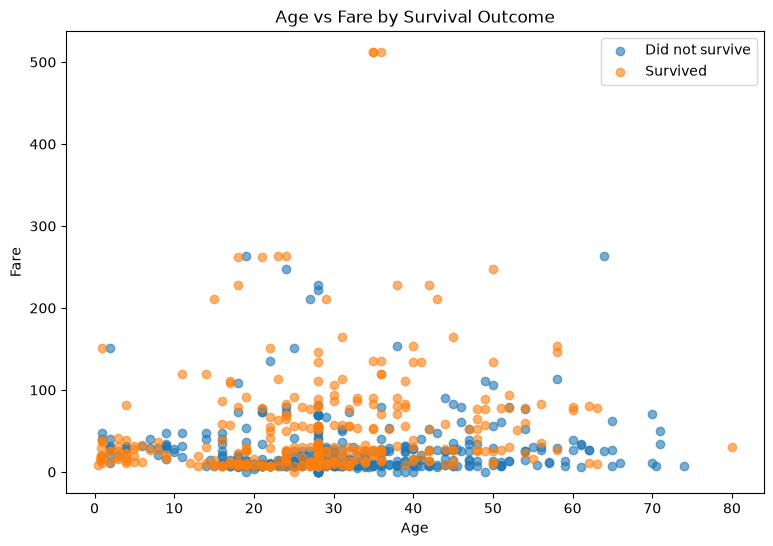

In [40]:
plt.figure(figsize=(9, 6))

survived = clean_df["survived"] == 1
not_survived = clean_df["survived"] == 0

plt.scatter(
    clean_df.loc[not_survived, "age"],
    clean_df.loc[not_survived, "fare"],
    alpha=0.6,
    label="Did not survive"
)

plt.scatter(
    clean_df.loc[survived, "age"],
    clean_df.loc[survived, "fare"],
    alpha=0.6,
    label="Survived"
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare by Survival Outcome")
plt.legend()

plt.show()

### Interpretation

The scatter plot shows substantial overlap between survivors and non-survivors across age and fare. Higher fares are concentrated among a smaller number of passengers, while most passengers paid relatively lower fares. Survival therefore cannot be explained by age and fare alone, reinforcing the importance of considering multiple passenger characteristics together.

Exploratory Standardization

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

clean_df[["age_standardized", "fare_standardized"]] = scaler.fit_transform(
    clean_df[["age", "fare"]]
)

In [43]:
print("Before standardization:")
print(
    clean_df[["age", "fare"]].agg(["mean", "std"])
)

Before standardization:
            age       fare
mean  29.361582  32.204208
std   13.019697  49.693429


In [44]:
print("\nAfter standardization:")
print(
    clean_df[["age_standardized", "fare_standardized"]].agg(["mean", "std"])
)


After standardization:
      age_standardized  fare_standardized
mean      2.272780e-16       3.987333e-18
std       1.000562e+00       1.000562e+00


### Standardization Interpretation

Age and fare were standardized using `StandardScaler` on the full cleaned DataFrame as an exploratory sanity check. The transformed variables have means approximately equal to 0 and standard deviations approximately equal to 1. This exploratory transformation is not used as the modeling preprocessing pipeline; model preprocessing will be fitted only on the training data to prevent data leakage.

In [45]:
clean_df.to_csv(
    "cleaned_titanic_eda.csv",
    index=False
)

print("Saved cleaned EDA dataset.")

Saved cleaned EDA dataset.
